# Contact Map Visualization

Compare model-generated vs ground-truth residue-residue contact maps as heatmaps.
Downloads a PDB structure, computes ground-truth atomic contacts, then generates
contacts from a trained exp4 checkpoint with varying prefix sizes.

In [1]:
# Config
CHECKPOINT_PATH = "../../outputs/exp4.celestial-plant-14/"  # auto-finds latest checkpoint-* subdir
PDB_ID = "1QYS"
CONTACT_DISTANCE_CUTOFF = 4.0  # Angstroms, for heavy atom contacts
MAX_NEW_TOKENS = 3440
PREFIX_SIZES = [0, 5, 10, 20]
N_ROLLOUTS = 10  # number of sampled rollouts per prefix size
DEVICE = "cuda"

In [2]:
# Download & parse PDB structure
import tempfile
import numpy as np
from biotite.database import rcsb
from biotite.structure.io import pdbx
from biotite.structure import filter_amino_acids
from experiments.exp4_contact_prediction.src.data import AMINO_ACIDS

# Map non-standard amino acids to their standard equivalents
NONSTANDARD_AA_MAP = {
    "MSE": "MET",  # selenomethionine -> methionine
    "CSE": "CYS",  # selenocysteine -> cysteine
    "SEC": "CYS",
    "HYP": "PRO",  # hydroxyproline -> proline
    "TPO": "THR",  # phosphothreonine -> threonine
    "SEP": "SER",  # phosphoserine -> serine
    "PTR": "TYR",  # phosphotyrosine -> tyrosine
}

path = rcsb.fetch(PDB_ID, "cif", tempfile.gettempdir())
cif = pdbx.CIFFile.read(path)
atoms = pdbx.get_structure(cif.block, model=1)

# First chain, amino acids only, heavy atoms only
first_chain = atoms.chain_id[0]
chain_atoms = atoms[(atoms.chain_id == first_chain) & filter_amino_acids(atoms) & (atoms.element != "H")]

# Build residue list (1-indexed positions)
res_ids = chain_atoms.res_id
unique_res = sorted(set(res_ids))
res_id_to_pos = {rid: i + 1 for i, rid in enumerate(unique_res)}  # 1-indexed
sequence_raw = [chain_atoms[chain_atoms.res_id == rid].res_name[0] for rid in unique_res]

# Map non-standard residues to standard amino acids
aa_set = set(AMINO_ACIDS)
sequence = []
for aa in sequence_raw:
    if aa in aa_set:
        sequence.append(aa)
    elif aa in NONSTANDARD_AA_MAP:
        print(f"  Mapping non-standard residue: {aa} -> {NONSTANDARD_AA_MAP[aa]}")
        sequence.append(NONSTANDARD_AA_MAP[aa])
    else:
        raise ValueError(f"Unknown amino acid: {aa} (add to NONSTANDARD_AA_MAP)")

seq_len = len(sequence)
print(f"Protein {PDB_ID}: {seq_len} residues, chain {first_chain}")
print(f"Sequence: {' '.join(sequence[:10])}...")

/home/ubuntu/llm-protein-experiments/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Mapping non-standard residue: MSE -> MET
Protein 1QYS: 92 residues, chain A
Sequence: ASP ILE GLN VAL GLN VAL ASN ILE ASP ASP...


In [3]:
# Compute ground-truth contacts (one per residue pair, closest atom pair)
from scipy.spatial import distance as sp_distance
from experiments.exp4_contact_prediction.src.data import VALID_ATOMS

coords = chain_atoms.coord
atom_names = chain_atoms.atom_name
atom_res_ids = chain_atoms.res_id

all_known_atoms = set()
for aa in VALID_ATOMS:
    all_known_atoms.update(VALID_ATOMS[aa])

# Collect all valid atom-level contacts with distances
all_atom_contacts = []  # (pos1, pos2, atom1, atom2, distance)
n_atoms = len(coords)
from scipy.spatial import KDTree
tree = KDTree(coords)
pairs = tree.query_pairs(r=CONTACT_DISTANCE_CUTOFF)

for i, j in pairs:
    ri, rj = atom_res_ids[i], atom_res_ids[j]
    pi, pj = res_id_to_pos.get(ri), res_id_to_pos.get(rj)
    if pi is None or pj is None:
        continue
    if abs(pi - pj) < 2:
        continue
    ai, aj = str(atom_names[i]), str(atom_names[j])
    if ai not in all_known_atoms or aj not in all_known_atoms:
        continue
    aa_i, aa_j = sequence[pi - 1], sequence[pj - 1]
    if aa_i not in VALID_ATOMS or ai not in VALID_ATOMS[aa_i]:
        continue
    if aa_j not in VALID_ATOMS or aj not in VALID_ATOMS[aa_j]:
        continue
    dist = float(np.linalg.norm(coords[i] - coords[j]))
    # Canonical ordering: smaller position first
    if pi > pj:
        all_atom_contacts.append((pj, pi, aj, ai, dist))
    else:
        all_atom_contacts.append((pi, pj, ai, aj, dist))

# Keep only the closest atom pair per residue pair (matching training data format)
best_per_pair = {}  # (pos1, pos2) -> (pos1, pos2, atom1, atom2, distance)
for contact in all_atom_contacts:
    pair_key = (contact[0], contact[1])
    if pair_key not in best_per_pair or contact[4] < best_per_pair[pair_key][4]:
        best_per_pair[pair_key] = contact

# Sort by decreasing sequence separation (matching training data ordering)
gt_contacts = [(p1, p2, a1, a2) for p1, p2, a1, a2, _ in
               sorted(best_per_pair.values(), key=lambda c: (-abs(c[0] - c[1]), c[0], c[1]))]

print(f"Ground-truth contacts: {len(gt_contacts)} (one per residue pair)")
print(f"First 5: {gt_contacts[:5]}")

# Build the document prompt
seq_tokens = " ".join(f"<{aa}>" for aa in sequence)
base_prompt = f"<deterministic-positives-only> <begin_sequence> {seq_tokens} <begin_contacts>"
print(f"\nPrompt length: {len(base_prompt.split())} tokens")

Ground-truth contacts: 257 (one per residue pair)
First 5: [(1, 51, 'O', 'O'), (2, 51, 'CA', 'O'), (43, 92, 'O', 'CD2'), (2, 50, 'CG2', 'CG2'), (3, 51, 'O', 'N')]

Prompt length: 95 tokens


In [4]:
#VALID_ATOMS

In [5]:
# Load model & tokenizer
import glob
import torch
from pathlib import Path
from transformers import LlamaForCausalLM
from experiments.exp4_contact_prediction.src.train import create_tokenizer, parse_generated_contacts

# Find latest checkpoint
ckpt_base = Path(CHECKPOINT_PATH)
ckpt_dirs = sorted(ckpt_base.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[1]))
if ckpt_dirs:
    ckpt_path = ckpt_dirs[-1]
else:
    ckpt_path = ckpt_base  # fallback: treat base as the checkpoint
print(f"Loading checkpoint: {ckpt_path}")

tokenizer = create_tokenizer()
model = LlamaForCausalLM.from_pretrained(str(ckpt_path), torch_dtype=torch.bfloat16)
model = model.to(DEVICE).eval()
print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")

Loading checkpoint: ../../outputs/exp4/checkpoint-99500


Loading weights: 100%|██████████| 147/147 [00:00<00:00, 391.37it/s, Materializing param=model.norm.weight]                              


Model loaded: 984,475,648 parameters


In [6]:
# Generate contacts: greedy + sampled rollouts for each prefix size
import time

end_token_id = tokenizer.convert_tokens_to_ids("<end>")
generated_contacts = {}  # prefix_size -> greedy contacts
rollout_contacts = {}    # prefix_size -> list of N_ROLLOUTS contact lists
timings = {}             # prefix_size -> {"greedy": seconds, "rollouts": [seconds, ...]}

def build_prompt(n_prefix):
    if n_prefix > 0 and gt_contacts:
        prefix_toks = []
        for p1, p2, a1, a2 in gt_contacts[:n_prefix]:
            prefix_toks.extend([f"<p{p1}>", f"<p{p2}>", f"<{a1}>", f"<{a2}>"])
        return base_prompt + " " + " ".join(prefix_toks)
    return base_prompt

def run_generation(prompt, do_sample=False):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=8192)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    gen_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=end_token_id,
    )
    if do_sample:
        gen_kwargs.update(do_sample=True, temperature=1.0, top_k=0)
    else:
        gen_kwargs.update(do_sample=False)

    t0 = time.time()
    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_kwargs)
    elapsed = time.time() - t0

    gen_ids = outputs[0][inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=False)
    contacts, valid_grammar = parse_generated_contacts(gen_text.split())
    return contacts, valid_grammar, elapsed

for n_prefix in PREFIX_SIZES:
    prompt = build_prompt(n_prefix)
    timing_info = {}

    # Greedy
    contacts, valid, elapsed = run_generation(prompt, do_sample=False)
    if n_prefix > 0:
        contacts = list(gt_contacts[:n_prefix]) + list(contacts)
    generated_contacts[n_prefix] = contacts
    timing_info["greedy"] = elapsed
    print(f"Prefix {n_prefix:2d} greedy: {len(contacts):4d} contacts, valid={valid}, {elapsed:.1f}s")

    # Sampled rollouts
    rollouts = []
    rollout_times = []
    for r in range(N_ROLLOUTS):
        contacts_r, valid_r, elapsed_r = run_generation(prompt, do_sample=True)
        if n_prefix > 0:
            contacts_r = list(gt_contacts[:n_prefix]) + list(contacts_r)
        rollouts.append(contacts_r)
        rollout_times.append(elapsed_r)
    rollout_contacts[n_prefix] = rollouts
    timing_info["rollouts"] = rollout_times
    timings[n_prefix] = timing_info
    avg_t = np.mean(rollout_times)
    print(f"  rollouts: {N_ROLLOUTS}x, avg {avg_t:.1f}s each")

Prefix  0 greedy:  227 contacts, valid=True, 18.2s
  rollouts: 10x, avg 13.6s each
Prefix  5 greedy:  230 contacts, valid=True, 14.2s
  rollouts: 10x, avg 18.5s each
Prefix 10 greedy:  231 contacts, valid=True, 18.3s
  rollouts: 10x, avg 19.2s each
Prefix 20 greedy:  228 contacts, valid=True, 17.6s
  rollouts: 10x, avg 19.0s each


In [7]:
# Build contact matrices (greedy + rollout frequency)
def contacts_to_matrix(contacts, seq_len):
    """Convert contact list to symmetric NxN binary matrix."""
    matrix = np.zeros((seq_len, seq_len), dtype=np.float32)
    for p1, p2, a1, a2 in contacts:
        if 1 <= p1 <= seq_len and 1 <= p2 <= seq_len:
            matrix[p1 - 1, p2 - 1] = 1
            matrix[p2 - 1, p1 - 1] = 1
    return matrix

def contacts_to_pair_set(contacts):
    return {(min(c[0], c[1]), max(c[0], c[1])) for c in contacts}

gt_matrix = contacts_to_matrix(gt_contacts, seq_len)
gt_pair_set = contacts_to_pair_set(gt_contacts)

# Greedy: separate prefix and generated-only matrices + accuracy
prefix_matrices = {}
gen_only_matrices = {}
gen_accuracy = {}

for n_prefix, contacts in generated_contacts.items():
    prefix_contacts = contacts[:n_prefix] if n_prefix > 0 else []
    gen_only_contacts = contacts[n_prefix:] if n_prefix > 0 else contacts

    prefix_matrices[n_prefix] = contacts_to_matrix(prefix_contacts, seq_len)
    gen_only_matrices[n_prefix] = contacts_to_matrix(gen_only_contacts, seq_len)

    gen_pairs = contacts_to_pair_set(gen_only_contacts)
    n_gen = len(gen_pairs)
    n_correct = len(gen_pairs & gt_pair_set)
    precision = n_correct / n_gen if n_gen > 0 else 0.0
    recall = n_correct / len(gt_pair_set) if gt_pair_set else 0.0
    gen_accuracy[n_prefix] = {
        "n_gen_pairs": n_gen, "n_correct": n_correct,
        "precision": precision, "recall": recall,
    }

# Rollout frequency matrices (fraction of rollouts containing each residue pair)
rollout_freq_matrices = {}
rollout_accuracy = {}

for n_prefix, rollouts in rollout_contacts.items():
    freq = np.zeros((seq_len, seq_len), dtype=np.float32)
    for contacts in rollouts:
        gen_only = contacts[n_prefix:] if n_prefix > 0 else contacts
        m = contacts_to_matrix(gen_only, seq_len)
        freq += m
    freq /= len(rollouts)
    rollout_freq_matrices[n_prefix] = freq

    # Accuracy: a pair is "predicted" if it appears in >50% of rollouts
    predicted_pairs = set()
    for i in range(seq_len):
        for j in range(i + 1, seq_len):
            if freq[i, j] > 0.5:
                predicted_pairs.add((i + 1, j + 1))
    n_pred = len(predicted_pairs)
    n_correct = len(predicted_pairs & gt_pair_set)
    precision = n_correct / n_pred if n_pred > 0 else 0.0
    recall = n_correct / len(gt_pair_set) if gt_pair_set else 0.0
    rollout_accuracy[n_prefix] = {
        "n_pred_pairs": n_pred, "n_correct": n_correct,
        "precision": precision, "recall": recall,
    }

print(f"Ground truth: {len(gt_pair_set)} unique residue pairs\n")
print("Greedy:")
for k, acc in gen_accuracy.items():
    print(f"  Prefix {k:2d}: {acc['n_gen_pairs']} gen pairs, "
          f"{acc['n_correct']} correct, "
          f"prec={acc['precision']:.1%}, rec={acc['recall']:.1%}")
print(f"\nRollout consensus (>50% of {N_ROLLOUTS} rollouts):")
for k, acc in rollout_accuracy.items():
    print(f"  Prefix {k:2d}: {acc['n_pred_pairs']} pred pairs, "
          f"{acc['n_correct']} correct, "
          f"prec={acc['precision']:.1%}, rec={acc['recall']:.1%}")

Ground truth: 257 unique residue pairs

Greedy:
  Prefix  0: 227 gen pairs, 138 correct, prec=60.8%, rec=53.7%
  Prefix  5: 225 gen pairs, 185 correct, prec=82.2%, rec=72.0%
  Prefix 10: 221 gen pairs, 181 correct, prec=81.9%, rec=70.4%
  Prefix 20: 208 gen pairs, 175 correct, prec=84.1%, rec=68.1%

Rollout consensus (>50% of 10 rollouts):
  Prefix  0: 127 pred pairs, 111 correct, prec=87.4%, rec=43.2%
  Prefix  5: 162 pred pairs, 147 correct, prec=90.7%, rec=57.2%
  Prefix 10: 161 pred pairs, 146 correct, prec=90.7%, rec=56.8%
  Prefix 20: 147 pred pairs, 136 correct, prec=92.5%, rec=52.9%


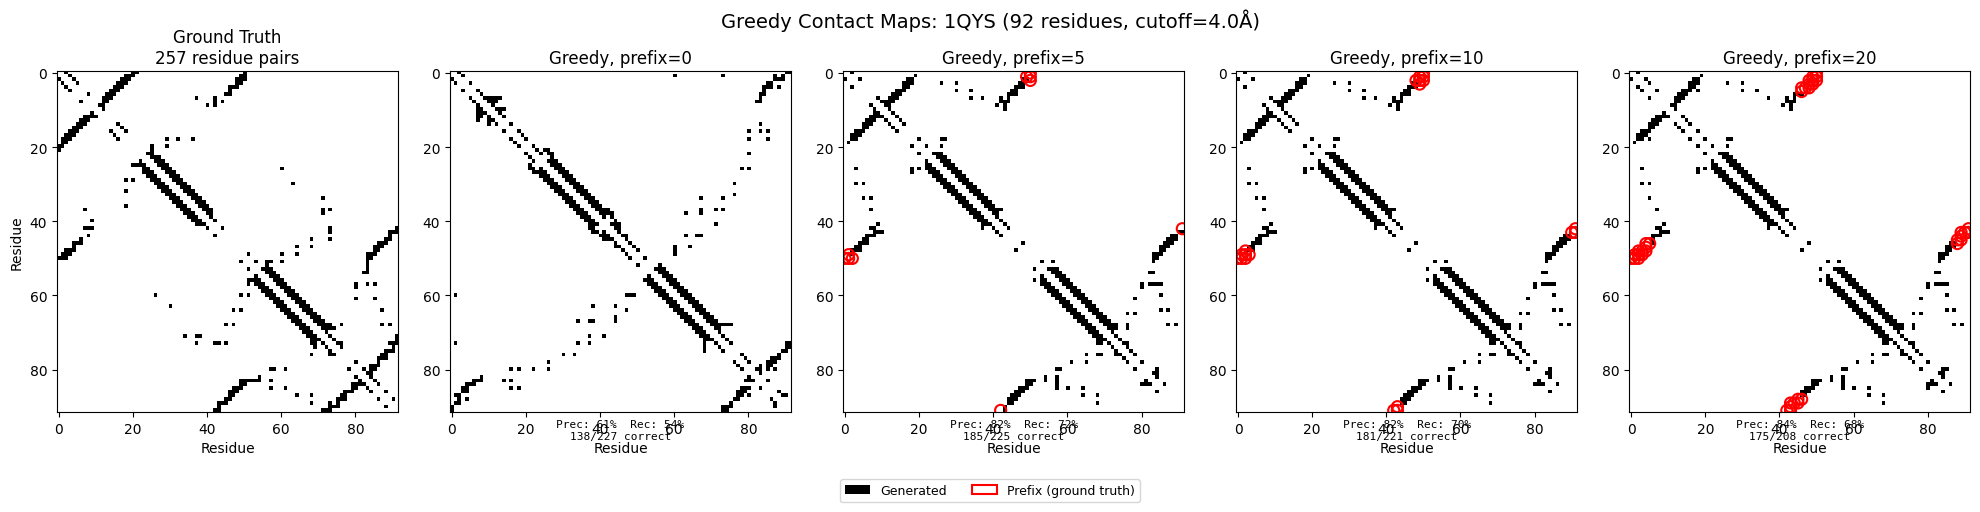

In [8]:
# Plot greedy heatmaps with red circles on prefix contacts
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Circle

n_cols = 1 + len(PREFIX_SIZES)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4.8), squeeze=False)
axes = axes[0]

cmap_gt = ListedColormap(["white", "black"])

# Ground truth
axes[0].imshow(gt_matrix, cmap=cmap_gt, vmin=0, vmax=1, origin="upper", aspect="equal")
axes[0].set_title(f"Ground Truth\n{len(gt_pair_set)} residue pairs")
axes[0].set_xlabel("Residue")
axes[0].set_ylabel("Residue")

# Generated panels
for i, n_prefix in enumerate(PREFIX_SIZES):
    ax = axes[i + 1]
    acc = gen_accuracy[n_prefix]

    # Show generated contacts in grey
    ax.imshow(gen_only_matrices[n_prefix], cmap=cmap_gt, vmin=0, vmax=1,
              origin="upper", aspect="equal")

    # Draw red circles around prefix contacts
    if n_prefix > 0:
        prefix_pairs_plotted = set()
        for p1, p2, a1, a2 in gt_contacts[:n_prefix]:
            pair = (min(p1, p2) - 1, max(p1, p2) - 1)
            if pair not in prefix_pairs_plotted:
                prefix_pairs_plotted.add(pair)
                for (r, c) in [(pair[0], pair[1]), (pair[1], pair[0])]:
                    circle = Circle((c, r), radius=1.5, fill=False,
                                    edgecolor="red", linewidth=1.5)
                    ax.add_patch(circle)

    ax.set_title(f"Greedy, prefix={n_prefix}")
    ax.set_xlabel("Residue")

    stats_text = (
        f"Prec: {acc['precision']:.0%}  Rec: {acc['recall']:.0%}\n"
        f"{acc['n_correct']}/{acc['n_gen_pairs']} correct"
    )
    ax.text(0.5, -0.02, stats_text, transform=ax.transAxes, ha="center", va="top",
            fontsize=8, fontfamily="monospace")

legend_elements = [
    Patch(facecolor="black", label="Generated"),
    Patch(facecolor="white", edgecolor="red", linewidth=1.5, label="Prefix (ground truth)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    f"Greedy Contact Maps: {PDB_ID} ({seq_len} residues, cutoff={CONTACT_DISTANCE_CUTOFF}\u00c5)",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

/tmp/ipykernel_3307032/2236543174.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


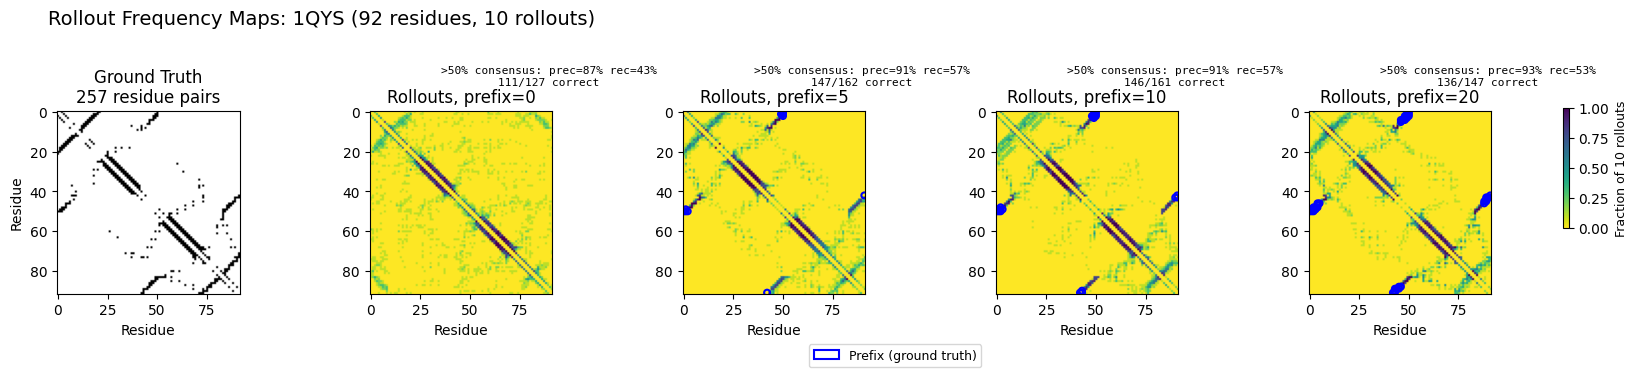

In [9]:
# Plot rollout frequency heatmaps (soft contact maps)
n_cols = 1 + len(PREFIX_SIZES)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5.2), squeeze=False)
axes = axes[0]

# Ground truth (binary) for reference
axes[0].imshow(gt_matrix, cmap="Greys", vmin=0, vmax=1, origin="upper", aspect="equal")
axes[0].set_title(f"Ground Truth\n{len(gt_pair_set)} residue pairs")
axes[0].set_xlabel("Residue")
axes[0].set_ylabel("Residue")

for i, n_prefix in enumerate(PREFIX_SIZES):
    ax = axes[i + 1]
    acc = rollout_accuracy[n_prefix]
    freq = rollout_freq_matrices[n_prefix]

    im = ax.imshow(freq, cmap="viridis_r", vmin=0, vmax=1, origin="upper", aspect="equal")

    # Draw red circles around prefix contacts
    if n_prefix > 0:
        prefix_pairs_plotted = set()
        for p1, p2, a1, a2 in gt_contacts[:n_prefix]:
            pair = (min(p1, p2) - 1, max(p1, p2) - 1)
            if pair not in prefix_pairs_plotted:
                prefix_pairs_plotted.add(pair)
                for (r, c) in [(pair[0], pair[1]), (pair[1], pair[0])]:
                    circle = Circle((c, r), radius=1.5, fill=False,
                                    edgecolor="blue", linewidth=1.5)
                    ax.add_patch(circle)

    ax.set_title(f"Rollouts, prefix={n_prefix}")
    ax.set_xlabel("Residue")

    stats_text = (
        f">50% consensus: prec={acc['precision']:.0%} rec={acc['recall']:.0%}\n"
        f"{acc['n_correct']}/{acc['n_pred_pairs']} correct"
    )
    ax.text(0.98, 1.25, stats_text, transform=ax.transAxes, ha="center", va="top",
            fontsize=8, fontfamily="monospace")

# Colorbar
cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.3, pad=-0.4)
cbar.set_label(f"Fraction of {N_ROLLOUTS} rollouts", fontsize=9)

legend_elements = [
    Patch(facecolor="white", edgecolor="blue", linewidth=1.5, label="Prefix (ground truth)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=1, fontsize=9,
           bbox_to_anchor=(0.45, 0.1))

fig.suptitle(
    f"Rollout Frequency Maps: {PDB_ID} ({seq_len} residues, {N_ROLLOUTS} rollouts)",
    fontsize=14, y=0.80, x=0.3, ha="right",
)
plt.tight_layout()
#plt.subplots_adjust(bottom=0.01)
plt.show()

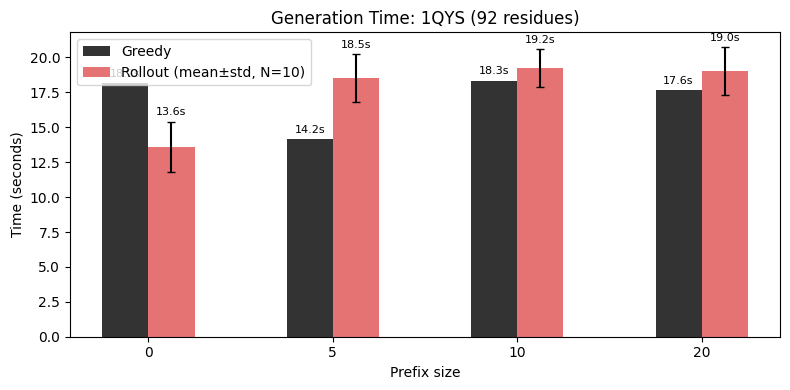

In [10]:
# Plot generation timings
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(PREFIX_SIZES))
width = 0.25

# Greedy times
greedy_times = [timings[p]["greedy"] for p in PREFIX_SIZES]
bars1 = ax.bar(x - width/2, greedy_times, width, label="Greedy", color="#333333")

# Rollout times (mean + std)
rollout_means = [np.mean(timings[p]["rollouts"]) for p in PREFIX_SIZES]
rollout_stds = [np.std(timings[p]["rollouts"]) for p in PREFIX_SIZES]
bars2 = ax.bar(x + width/2, rollout_means, width, yerr=rollout_stds,
               label=f"Rollout (mean±std, N={N_ROLLOUTS})", color="#E57373", capsize=3)

ax.set_xlabel("Prefix size")
ax.set_ylabel("Time (seconds)")
ax.set_title(f"Generation Time: {PDB_ID} ({seq_len} residues)")
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in PREFIX_SIZES])
ax.legend()

# Annotate bars with values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}s", ha="center", va="bottom", fontsize=8)
for bar, std in zip(bars2, rollout_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.3,
            f"{bar.get_height():.1f}s", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()
